# Soccer Player Clasification
## Bibliotecas

In [58]:
import pandas as pd
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.decomposition import PCA

## Carga del dataset

In [59]:
df = pd.read_csv("data/fifa_players.csv")
print(df.head)

<bound method NDFrame.head of                  name                         full_name birth_date  age  \
0            L. Messi    Lionel Andrés Messi Cuccittini  6/24/1987   31   
1          C. Eriksen      Christian  Dannemann Eriksen  2/14/1992   27   
2            P. Pogba                        Paul Pogba  3/15/1993   25   
3          L. Insigne                   Lorenzo Insigne   6/4/1991   27   
4        K. Koulibaly                 Kalidou Koulibaly  6/20/1991   27   
...               ...                               ...        ...  ...   
17949     R. McKenzie                    Rory  McKenzie  10/7/1993   25   
17950       M. Sipľak                     Michal Sipľak   2/2/1996   23   
17951      J. Bekkema                       Jan Bekkema   4/9/1996   22   
17952      A. Al Yami               Abdulrahman Al Yami  6/19/1997   21   
17953  Júnior Brumado  José Francisco dos Santos Júnior  5/15/1999   19   

       height_cm  weight_kgs  positions   nationality  overall_rating

### Comprensión de los datos

In [60]:
#print(y)
print("DISTRIBUCION DE LAS CLASES POR POSICIÓN: \n",df["positions"].value_counts())
print("VALORES NULOS POR VARIABLE: \n",df.isnull().sum()) #Valores nulos por variable
print("TIPOS DE DATOS: \n",df.dtypes) #reconocer los tipos de datos

DISTRIBUCION DE LAS CLASES POR POSICIÓN: 
 positions
CB              2243
GK              2065
ST              1747
CM               764
CDM,CM           709
                ... 
LB,CM,LWB          1
CF,ST,LM,RM        1
CAM,CM,RW,LW       1
CF,LM,RM           1
CF,CAM,CM          1
Name: count, Length: 890, dtype: int64
VALORES NULOS POR VARIABLE: 
 name                                 0
full_name                            0
birth_date                           0
age                                  0
height_cm                            0
weight_kgs                           0
positions                            0
nationality                          0
overall_rating                       0
potential                            0
value_euro                         255
wage_euro                          246
preferred_foot                       0
international_reputation(1-5)        0
weak_foot(1-5)                       0
skill_moves(1-5)                     0
body_type              

## Preparación de los datos

In [61]:
#Transformación de variables
df["preferred_foot"] = df["preferred_foot"].map({"Right": 1, "Left": 0}) #Mapeo de la variable preferred_foot
df["position"] = df["positions"].apply(lambda x: x.split(",")[0].strip()) #Tomar solo la primera posición de los strings

#Seleccion manual de las variables a trabajar 
features = ["age", "weak_foot(1-5)", "height_cm", "weight_kgs", "preferred_foot", "skill_moves(1-5)", "crossing", "finishing", "heading_accuracy", "short_passing", "volleys", "dribbling", "curve", "freekick_accuracy", "long_passing", "ball_control", "acceleration", "sprint_speed", "agility", "reactions", "balance", "shot_power", "jumping", "stamina", "strength", "long_shots", "aggression", "interceptions", "positioning", "vision", "composure", "marking", "standing_tackle", "sliding_tackle"]
target = "position"
X = df[features]
y = df[target]

# Escalar y aplicar PCA para un analisis exploratorio
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=0.95)
X_pca = pca.fit_transform(X_scaled) 

#  lista ordenada por importancia de las variables originales por su contribución total a todos los componentes
componentes = pd.DataFrame(pca.components_,columns=X.columns)
importancia = componentes.abs().sum(axis=0).sort_values(ascending=False)
print("LAS 15 VARIABLES MÁS IMPORTANTES: \n",importancia[:15])
top15 = importancia[:15].index.tolist()
X = df[top15]

LAS 15 VARIABLES MÁS IMPORTANTES: 
 reactions           3.608646
weight_kgs          3.524591
composure           3.373585
age                 3.108026
jumping             3.093635
strength            3.027748
height_cm           2.931880
stamina             2.741054
aggression          2.740509
vision              2.628510
balance             2.622800
long_passing        2.532271
sprint_speed        2.531827
skill_moves(1-5)    2.501448
preferred_foot      2.491600
dtype: float64


## Muestra de la distribución de los datos con las 3 variables más importantes

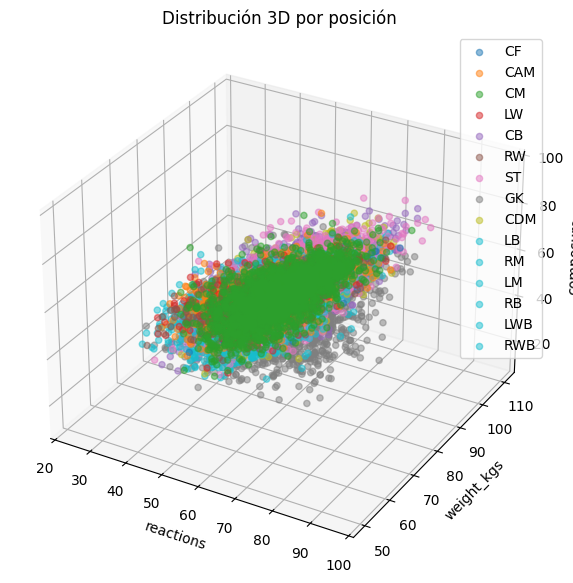

In [62]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Mapear categorías a colores
categorias = df["position"].unique()
colores = plt.cm.tab10(range(len(categorias)))
color_map = dict(zip(categorias, colores))

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

for categoria, color in color_map.items():
    mask = df["position"] == categoria
    ax.scatter(
        X[mask].iloc[:, 0],
        X[mask].iloc[:, 1],
        X[mask].iloc[:, 2],
        label=categoria,
        color=color,
        alpha=0.5
    )

ax.set_xlabel(top15[0])
ax.set_ylabel(top15[1])
ax.set_zlabel(top15[2])
plt.title("Distribución 3D por posición")
plt.legend()
plt.show()